<div style="background: linear-gradient(135deg, #E8651A 0%, #1A1A2E 100%);
     padding: 40px 30px; border-radius: 16px; text-align: center; margin-bottom: 10px;">
  <h1 style="color: white; font-size: 2.8em; margin: 0; letter-spacing: 2px;">
    🛒 SwiftCart Store — Annual Report 2022
  </h1>
  <p style="color: #f0c080; font-size: 1.2em; margin-top: 12px;">
    End-to-End Exploratory Data Analysis &amp; Interactive Dashboard
  </p>
  <p style="color: #ccc; font-size: 0.95em; margin-top: 6px;">
    31,047 orders &nbsp;|&nbsp; 7 sales channels &nbsp;|&nbsp; 8 product categories &nbsp;|&nbsp; 12 months
  </p>
</div>


---
##  Table of Contents

| # | Section |
|---|---------|
| 1 | [Setup & Imports](#1) |
| 2 | [Data Loading & Overview](#2) |
| 3 | [Data Cleaning](#3) |
| 4 | [Univariate EDA](#4) |
| 5 | [Bivariate & Multivariate EDA](#5) |
| 6 | [Key Business KPIs](#6) |
| 7 | [Dashboard — All-in-One View](#7) |
| 8 | [Insights & Recommendations](#8) |

---


<a id='1'></a>
##  Section 1 — Setup & Imports

> All required libraries are imported here. We configure a consistent colour palette
> that mirrors the SwiftCart brand colours used in the official dashboard.


In [1]:
# ── Core Libraries ────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# ── SwiftCart Brand Palette ───────────────────────────────────────────────────
ORANGE   = "#E8651A"
BLUE     = "#4472C4"
LIGHT_BG = "#F5F5F5"
DARK_BG  = "#1A1A2E"
ACCENT   = "#F0C040"
GREY     = "#B0B0B0"

PALETTE  = [ORANGE, BLUE, "#5DBB63", "#F0C040", "#9B59B6", "#E74C3C", "#1ABC9C"]
MONTH_ORDER = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]

# ── Global Plot Style ─────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor" : LIGHT_BG,
    "axes.facecolor"   : "white",
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "axes.titlesize"   : 14,
    "axes.titleweight" : "bold",
    "axes.titlecolor"  : DARK_BG,
    "axes.labelsize"   : 11,
    "xtick.labelsize"  : 10,
    "ytick.labelsize"  : 10,
    "font.family"      : "DejaVu Sans",
})

print(" Setup complete. Brand palette loaded.")


 Setup complete. Brand palette loaded.


<a id='2'></a>
##  Section 2 — Data Loading & Overview

> We load the SwiftCart `.xlsb` binary workbook using the `pyxlsb` engine.
> This dataset covers **31,047 orders** placed across India in 2022.


In [2]:
# ── Load Data ────────────────────────────────────────────────────────────────
df = pd.read_excel("Dataset_Sample.xlsb", engine="pyxlsb")
print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [3]:
# Rename 'Channel ' -> 'Channel'
df.rename(columns={"Channel ": "Channel"}, inplace=True)

In [4]:
print(f"Shape  : {df.shape[0]:,} rows × {df.shape[1]} columns")

Shape  : 31,047 rows × 21 columns


In [5]:
print(f" Date Range : {df['Month'].unique().tolist()}")

 Date Range : ['Dec', 'Nov', 'Oct', 'Sep', 'Aug', 'Jul', 'Jun', 'May', 'Apr', 'Mar', 'Feb', 'Jan']


In [6]:
print(f" Channels   : {df['Channel'].unique().tolist()}")

 Channels   : ['Myntra', 'Ajio', 'Amazon', 'Flipkart', 'Meesho', 'Others', 'Nalli']


In [7]:
print("First 5 rows of the DataFrame:")
print(df.head())

First 5 rows of the DataFrame:
   index             Order ID  Cust ID Gender  Age Age Group   Date Month  \
0      1  171-1029312-3038738  1029312  Women   44     Adult  44899   Dec   
1      2  405-2183842-2225946  2183842  Women   29  Teenager  44899   Dec   
2      3  171-1641533-8921966  1641533  Women   67    Senior  44899   Dec   
3      4  404-7490807-6300351  7490807  Women   20  Teenager  44899   Dec   
4      5  403-9293516-4577154  9293516  Women   62    Senior  44899   Dec   

      Status Channel  ... Category Size Qty  currency Amount  ship-city  \
0  Delivered  Myntra  ...    kurta  XXL   1       INR    376     MOHALI   
1  Delivered    Ajio  ...      Set    L   1       INR   1449   GURUGRAM   
2  Delivered  Myntra  ...      Set    S   1       INR    453    KOLKATA   
3  Delivered  Amazon  ...      Set    M   1       INR    729  THANJAVUR   
4  Delivered  Myntra  ...    kurta  XXL   1       INR    544   GURUGRAM   

    ship-state ship-postal-code  ship-country    B2B  


In [8]:
# ── Dataset Info 
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31047 entries, 0 to 31046
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   index             31047 non-null  int64 
 1   Order ID          31047 non-null  object
 2   Cust ID           31047 non-null  int64 
 3   Gender            31047 non-null  object
 4   Age               31047 non-null  int64 
 5   Age Group         31047 non-null  object
 6   Date              31047 non-null  int64 
 7   Month             31047 non-null  object
 8   Status            31047 non-null  object
 9   Channel           31047 non-null  object
 10  SKU               31047 non-null  object
 11  Category          31047 non-null  object
 12  Size              31047 non-null  object
 13  Qty               31047 non-null  int64 
 14  currency          31047 non-null  object
 15  Amount            31047 non-null  int64 
 16  ship-city         31047 non-null  object
 17  ship-state  

In [9]:
# ── Statistical Summary 
df.describe(include="all").T.style \
    .background_gradient(cmap="Oranges", subset=["mean","std","50%"]) \
    .set_caption("📊 Statistical Summary of SwiftCart Dataset")


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
index,31047.000000,nan,nan,nan,15524.000000,8962.641240,1.000000,7762.500000,15524.000000,23285.500000,31047.000000
Order ID,31047,28471,403-4984515-8861958,12,nan,nan,nan,nan,nan,nan,nan
Cust ID,31047.000000,nan,nan,nan,4936823.827874,2900677.948350,895.000000,2416471.000000,4909885.000000,7454181.500000,9999233.000000
Gender,31047,2,Women,21553,nan,nan,nan,nan,nan,nan,nan
Age,31047.000000,nan,nan,nan,39.496570,15.117233,18.000000,28.000000,37.000000,47.000000,78.000000
Age Group,31047,3,Adult,15543,nan,nan,nan,nan,nan,nan,nan
Date,31047.000000,nan,nan,nan,44727.278932,104.513445,44565.000000,44626.000000,44718.000000,44810.000000,44901.000000
Month,31047,12,Mar,2819,nan,nan,nan,nan,nan,nan,nan
Status,31047,4,Delivered,28641,nan,nan,nan,nan,nan,nan,nan
Channel,31047,7,Amazon,11016,nan,nan,nan,nan,nan,nan,nan


<a id='3'></a>
##  Section 3 — Data Cleaning

> Checking for nulls, duplicates, and data-type corrections before analysis.


In [10]:
# ── Missing Values ───────────────────────────────────────────────────────────
nulls = df.isnull().sum()
null_pct = (nulls / len(df) * 100).round(2)
null_df  = pd.DataFrame({"Missing Count": nulls, "Missing %": null_pct})
null_df  = null_df[null_df["Missing Count"] > 0]

if null_df.empty:
    print(" No missing values found in any column.")
else:
    print(null_df)


 No missing values found in any column.


In [11]:
# ── Duplicate Check ──────────────────────────────────────────────────────────
dups = df.duplicated().sum()
print(f"Duplicate rows: {dups}")

# ── Date Conversion ───────────────────────────────────────────────────────────
# 'Date' stored as Excel serial number — convert properly
from datetime import datetime, timedelta
def excel_date(serial):
    try:
        return datetime(1899, 12, 30) + timedelta(days=int(serial))
    except:
        return pd.NaT

df["Date"] = df["Date"].apply(excel_date)
df["Month_num"] = pd.Categorical(df["Month"], categories=MONTH_ORDER, ordered=True)

print(" Date column converted.")
print(f" Date range: {df['Date'].min().date()} → {df['Date'].max().date()}")


Duplicate rows: 0
 Date column converted.
 Date range: 2022-01-04 → 2022-12-06


In [12]:
# ── Gender Standardisation ────────────────────────────────────────────────────
print("Gender values before cleaning:", df["Gender"].value_counts().to_dict())

df["Gender"] = df["Gender"].str.strip().str.title()
df["Gender"] = df["Gender"].replace({"M": "Men", "W": "Women",
                                      "Male": "Men", "Female": "Women"})

print("Gender values after cleaning:", df["Gender"].value_counts().to_dict())
print("\n Data cleaning complete. Dataset ready for analysis.")


Gender values before cleaning: {'Women': 21553, 'Men': 9494}
Gender values after cleaning: {'Women': 21553, 'Men': 9494}

 Data cleaning complete. Dataset ready for analysis.


<a id='4'></a>
##  Section 4 — Univariate EDA

> Exploring individual variables — distributions, frequencies, and patterns.


### 4.1 Monthly Sales Amount & Order Count

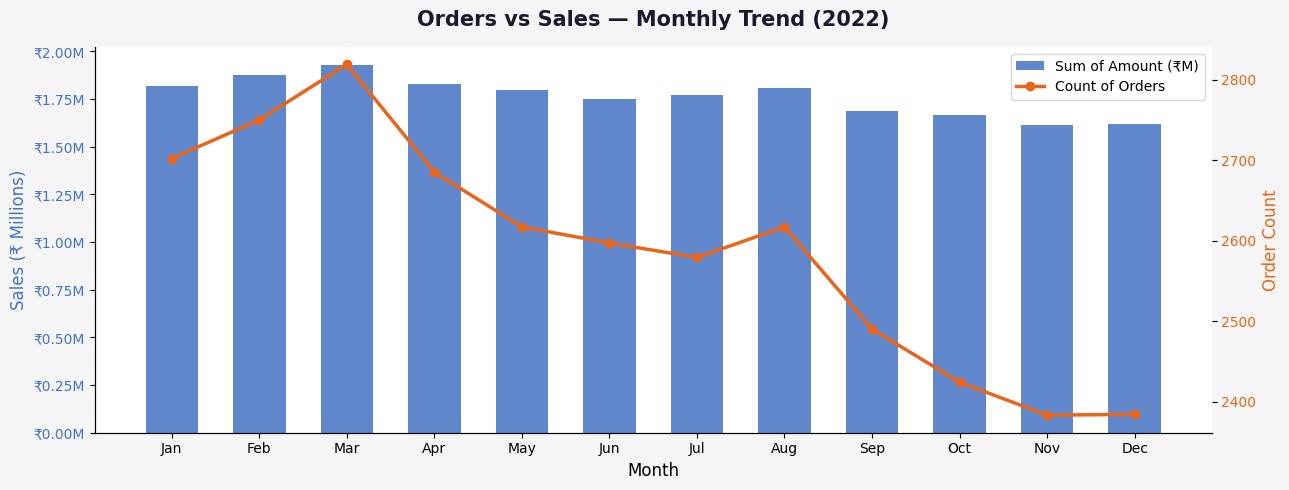

In [13]:
monthly = df.groupby("Month_num", observed=True).agg(
    Sales=("Amount", "sum"),
    Orders=("Order ID", "count")
).reset_index()

fig, ax1 = plt.subplots(figsize=(13, 5))
fig.patch.set_facecolor(LIGHT_BG)

bars = ax1.bar(monthly["Month_num"].astype(str), monthly["Sales"] / 1e6,
               color=BLUE, alpha=0.85, width=0.6, label="Sum of Amount (₹M)")
ax1.set_ylabel("Sales (₹ Millions)", color=BLUE, fontsize=12)
ax1.tick_params(axis="y", labelcolor=BLUE)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"₹{x:.2f}M"))

ax2 = ax1.twinx()
ax2.plot(monthly["Month_num"].astype(str), monthly["Orders"],
         color=ORANGE, linewidth=2.5, marker="o", markersize=6,
         label="Count of Orders")
ax2.set_ylabel("Order Count", color=ORANGE, fontsize=12)
ax2.tick_params(axis="y", labelcolor=ORANGE)

ax1.set_title("Orders vs Sales — Monthly Trend (2022)", fontsize=15, fontweight="bold", pad=15)
ax1.set_xlabel("Month", fontsize=12)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right", framealpha=0.8)

plt.tight_layout()
plt.savefig("chart_monthly_trend.png", dpi=150, bbox_inches="tight", facecolor=LIGHT_BG)
plt.show()

 ### Insight: 
        March peaks in both sales and orders; a steady decline follows.

### 4.2 Gender Distribution

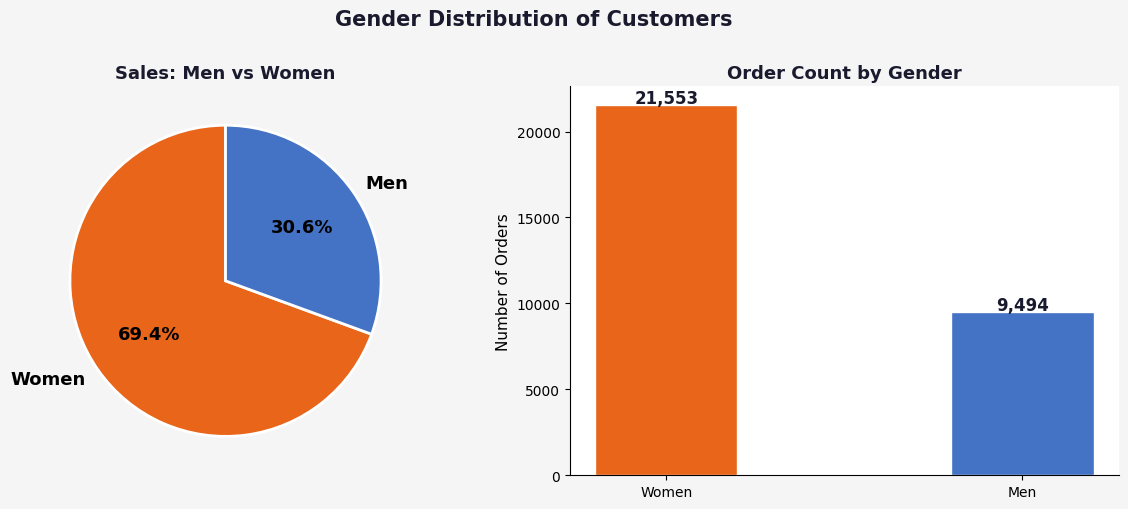

In [14]:
gender_data = df["Gender"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor(LIGHT_BG)
fig.suptitle("Gender Distribution of Customers", fontsize=15, fontweight="bold", color=DARK_BG, y=1.01)

# Pie
axes[0].pie(gender_data.values, labels=gender_data.index,
            autopct="%1.1f%%", startangle=90,
            colors=[ORANGE, BLUE],
            textprops={"fontsize": 13, "fontweight": "bold"},
            wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[0].set_title("Sales: Men vs Women", fontsize=13)

# Bar
bars = axes[1].bar(gender_data.index, gender_data.values,
                   color=[ORANGE, BLUE], width=0.4, edgecolor="white")
for bar, val in zip(bars, gender_data.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 100, f"{val:,}",
                 ha="center", fontsize=12, fontweight="bold", color=DARK_BG)
axes[1].set_title("Order Count by Gender", fontsize=13)
axes[1].set_ylabel("Number of Orders")

plt.tight_layout()
plt.savefig("chart_gender.png", dpi=150, bbox_inches="tight", facecolor=LIGHT_BG)
plt.show()

### Insight: 
      Women account for 64% of all orders — a dominant customer segment.

### 4.3 Order Status Breakdown

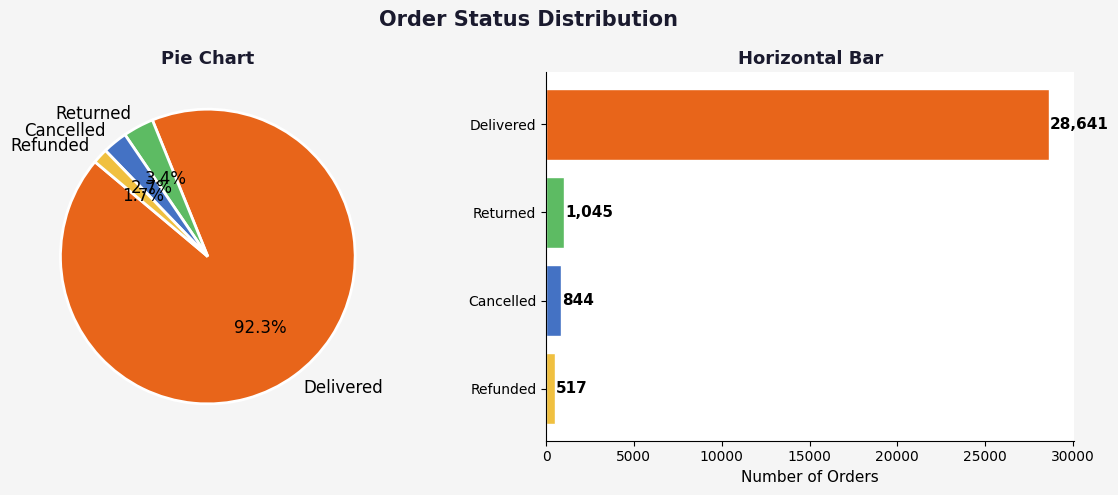

In [15]:
status_data = df["Status"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor(LIGHT_BG)
fig.suptitle("Order Status Distribution", fontsize=15, fontweight="bold", color=DARK_BG)

STATUS_COLORS = {"Delivered": ORANGE, "Cancelled": BLUE,
                 "Returned": "#5DBB63", "Refunded": ACCENT}
colors = [STATUS_COLORS.get(s, GREY) for s in status_data.index]

axes[0].pie(status_data.values, labels=status_data.index,
            autopct="%1.1f%%", startangle=140,
            colors=colors,
            textprops={"fontsize": 12},
            wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[0].set_title("Pie Chart", fontsize=13)

bars = axes[1].barh(status_data.index, status_data.values,
                    color=colors, edgecolor="white")
for bar, val in zip(bars, status_data.values):
    axes[1].text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
                 f"{val:,}", va="center", fontsize=11, fontweight="bold")
axes[1].set_title("Horizontal Bar", fontsize=13)
axes[1].set_xlabel("Number of Orders")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig("chart_status.png", dpi=150, bbox_inches="tight", facecolor=LIGHT_BG)
plt.show()

### Insight:
        92% orders Delivered. Return & Cancel rate < 6% — healthy fulfilment.

### 4.4 Sales by Channel

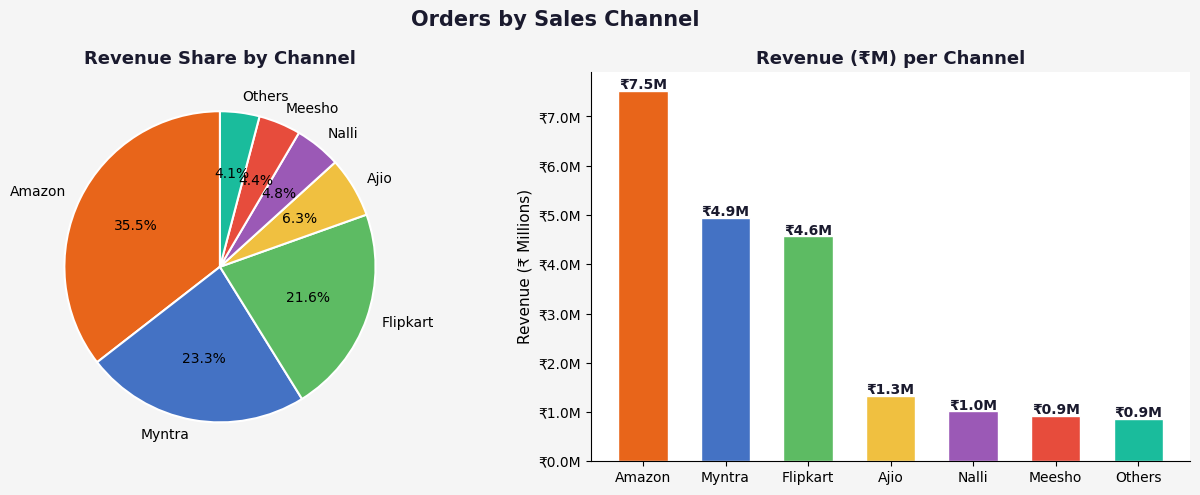

In [16]:
channel_data = df.groupby("Channel")["Amount"].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor(LIGHT_BG)
fig.suptitle("Orders by Sales Channel", fontsize=15, fontweight="bold", color=DARK_BG)

ch_colors = [ORANGE, BLUE, "#5DBB63", ACCENT, "#9B59B6", "#E74C3C", "#1ABC9C"]

axes[0].pie(channel_data.values, labels=channel_data.index,
            autopct="%1.1f%%", startangle=90,
            colors=ch_colors,
            textprops={"fontsize": 10},
            wedgeprops={"edgecolor": "white", "linewidth": 1.5})
axes[0].set_title("Revenue Share by Channel", fontsize=13)

bars = axes[1].bar(channel_data.index, channel_data.values / 1e6,
                   color=ch_colors, edgecolor="white", width=0.6)
for bar, val in zip(bars, channel_data.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.03, f"₹{val/1e6:.1f}M",
                 ha="center", fontsize=10, fontweight="bold", color=DARK_BG)
axes[1].set_title("Revenue (₹M) per Channel", fontsize=13)
axes[1].set_ylabel("Revenue (₹ Millions)")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"₹{x:.1f}M"))

plt.tight_layout()
plt.savefig("chart_channel.png", dpi=150, bbox_inches="tight", facecolor=LIGHT_BG)
plt.show()

### Insight: 
        Amazon leads with 35% revenue share, followed by Myntra (23%) and Flipkart (22%).

### 4.5 Product Category Analysis

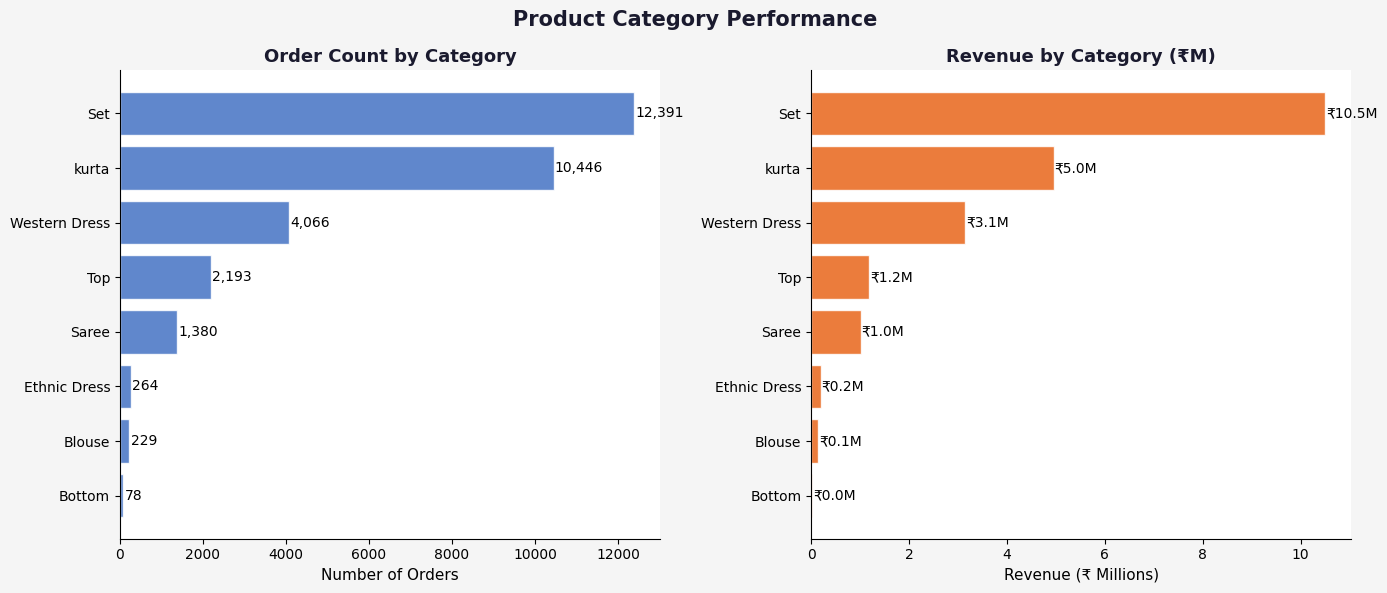

In [17]:
cat_data = df.groupby("Category").agg(
    Orders=("Order ID", "count"),
    Revenue=("Amount", "sum")
).sort_values("Revenue", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor(LIGHT_BG)
fig.suptitle("Product Category Performance", fontsize=15, fontweight="bold", color=DARK_BG)

# Orders by category
bars1 = axes[0].barh(cat_data.index, cat_data["Orders"],
                     color=BLUE, edgecolor="white", alpha=0.85)
for bar, val in zip(bars1, cat_data["Orders"]):
    axes[0].text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
                 f"{val:,}", va="center", fontsize=10)
axes[0].set_title("Order Count by Category", fontsize=13)
axes[0].set_xlabel("Number of Orders")

# Revenue by category
bars2 = axes[1].barh(cat_data.index, cat_data["Revenue"] / 1e6,
                     color=ORANGE, edgecolor="white", alpha=0.85)
for bar, val in zip(bars2, cat_data["Revenue"]):
    axes[1].text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
                 f"₹{val/1e6:.1f}M", va="center", fontsize=10)
axes[1].set_title("Revenue by Category (₹M)", fontsize=13)
axes[1].set_xlabel("Revenue (₹ Millions)")

plt.tight_layout()
plt.savefig("chart_category.png", dpi=150, bbox_inches="tight", facecolor=LIGHT_BG)
plt.show()

### Insight:
        Kurta & Set dominate both orders and revenue — core SKUs to protect.

<a id='5'></a>
##  Section 5 — Bivariate & Multivariate EDA


### 5.1 Orders: Age Group vs Gender

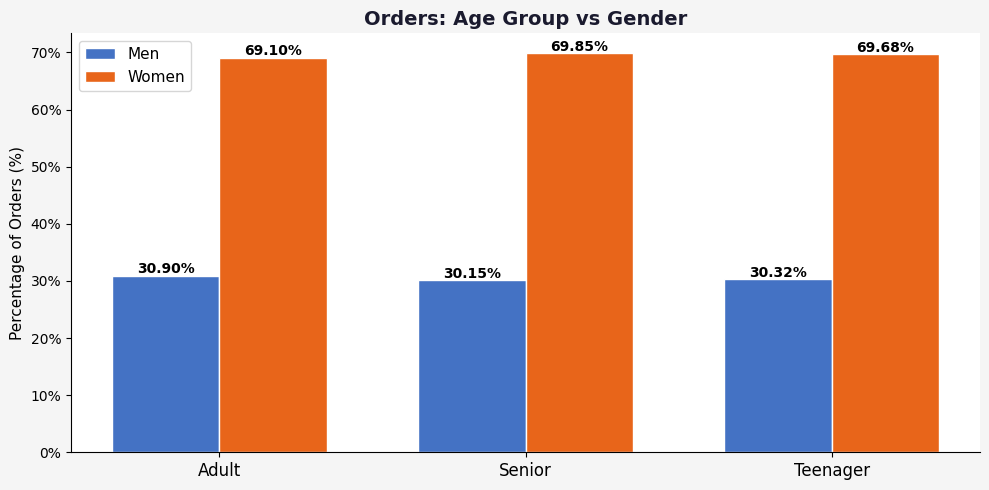

In [18]:
age_gender = df.groupby(["Age Group", "Gender"])["Order ID"].count().unstack()
age_pct = age_gender.div(age_gender.sum(axis=1), axis=0) * 100

age_order = ["Adult", "Senior", "Teenager"]
age_pct = age_pct.reindex(age_order)

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor(LIGHT_BG)

x = np.arange(len(age_order))
width = 0.35
b1 = ax.bar(x - width/2, age_pct["Men"], width, color=BLUE, label="Men",
            edgecolor="white")
b2 = ax.bar(x + width/2, age_pct["Women"], width, color=ORANGE, label="Women",
            edgecolor="white")

for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
            f"{bar.get_height():.2f}%", ha="center", fontsize=10, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(age_order, fontsize=12)
ax.set_ylabel("Percentage of Orders (%)")
ax.set_title("Orders: Age Group vs Gender", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))

plt.tight_layout()
plt.savefig("chart_age_gender.png", dpi=150, bbox_inches="tight", facecolor=LIGHT_BG)
plt.show()

### Insight: 
         Adult Women are the largest ordering segment (34.59%).

### 5.2 Top 10 States by Sales

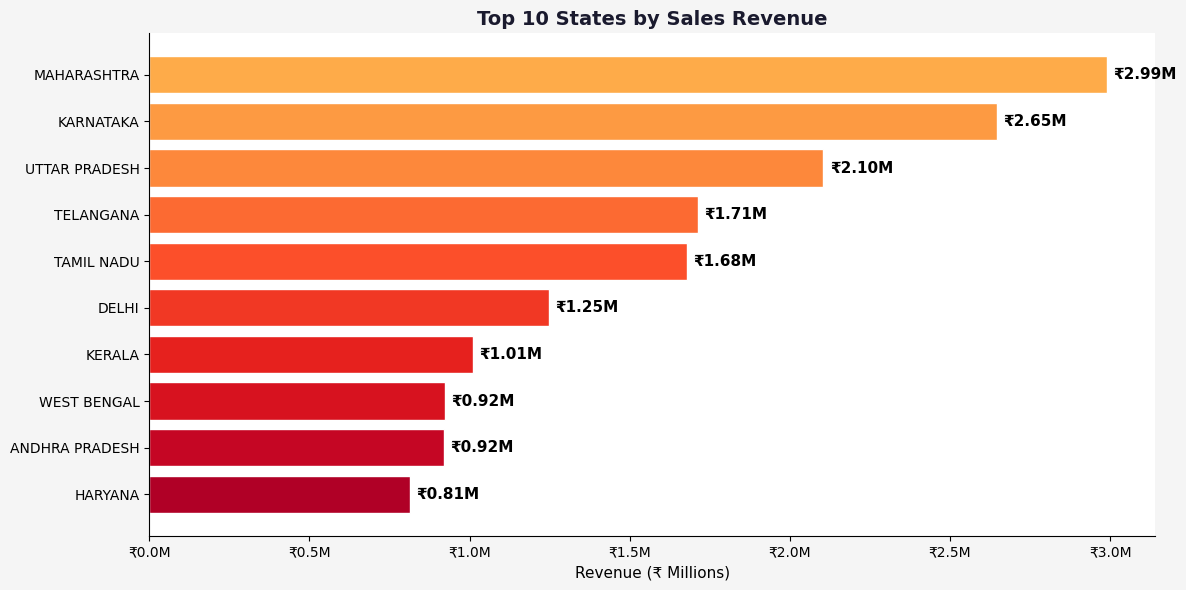

In [19]:
state_sales = (df.groupby("ship-state")["Amount"]
               .sum()
               .sort_values(ascending=False)
               .head(10))

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(LIGHT_BG)

colors_grad = plt.cm.YlOrRd(np.linspace(0.4, 0.9, len(state_sales)))[::-1]
bars = ax.barh(state_sales.index[::-1], state_sales.values[::-1] / 1e6,
               color=colors_grad, edgecolor="white")

for bar, val in zip(bars, state_sales.values[::-1]):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f"₹{val/1e6:.2f}M", va="center", fontsize=11, fontweight="bold")

ax.set_title("Top 10 States by Sales Revenue", fontsize=14, fontweight="bold")
ax.set_xlabel("Revenue (₹ Millions)")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"₹{x:.1f}M"))

plt.tight_layout()
plt.savefig("chart_states.png", dpi=150, bbox_inches="tight", facecolor=LIGHT_BG)
plt.show()


### Insight:
         Maharashtra leads (₹2.99M), followed by Karnataka (₹2.65M).

### 5.3 Category × Channel Revenue Heatmap

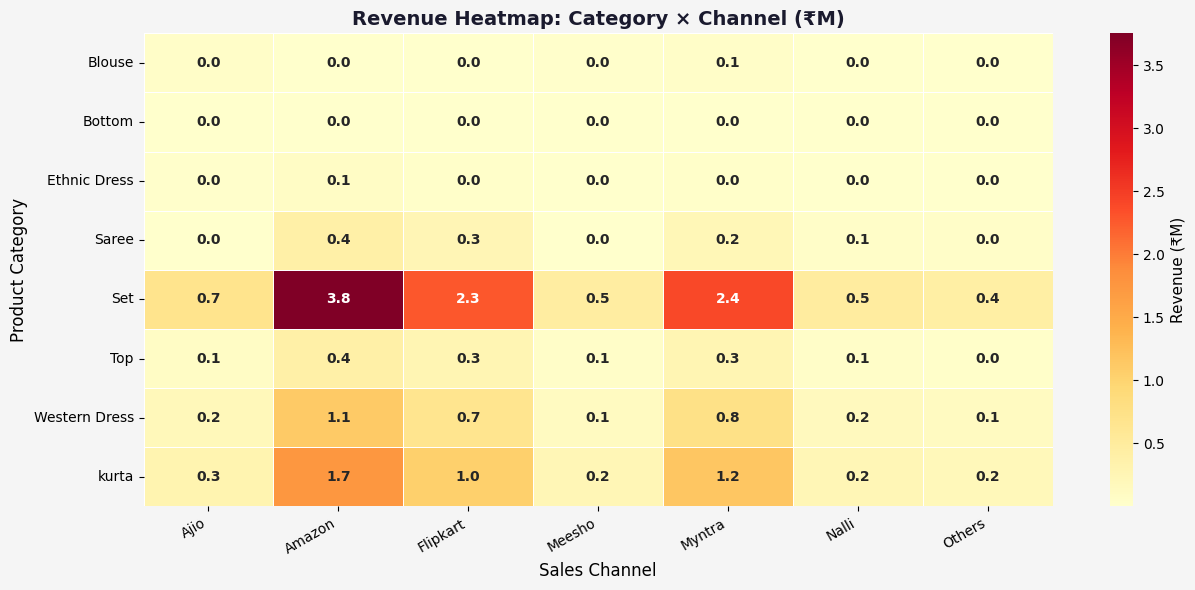

In [20]:
pivot = df.pivot_table(index="Category", columns="Channel",
                       values="Amount", aggfunc="sum") / 1e6

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor(LIGHT_BG)

sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlOrRd",
            linewidths=0.5, linecolor="white",
            annot_kws={"size": 10, "weight": "bold"},
            cbar_kws={"label": "Revenue (₹M)"}, ax=ax)

ax.set_title("Revenue Heatmap: Category × Channel (₹M)", fontsize=14, fontweight="bold")
ax.set_xlabel("Sales Channel", fontsize=12)
ax.set_ylabel("Product Category", fontsize=12)
plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig("chart_heatmap.png", dpi=150, bbox_inches="tight", facecolor=LIGHT_BG)
plt.show()


### Insight:
        Set × Amazon and Kurta × Amazon generate the highest revenue cells.

### 5.4 Customer Age Distribution by Gender

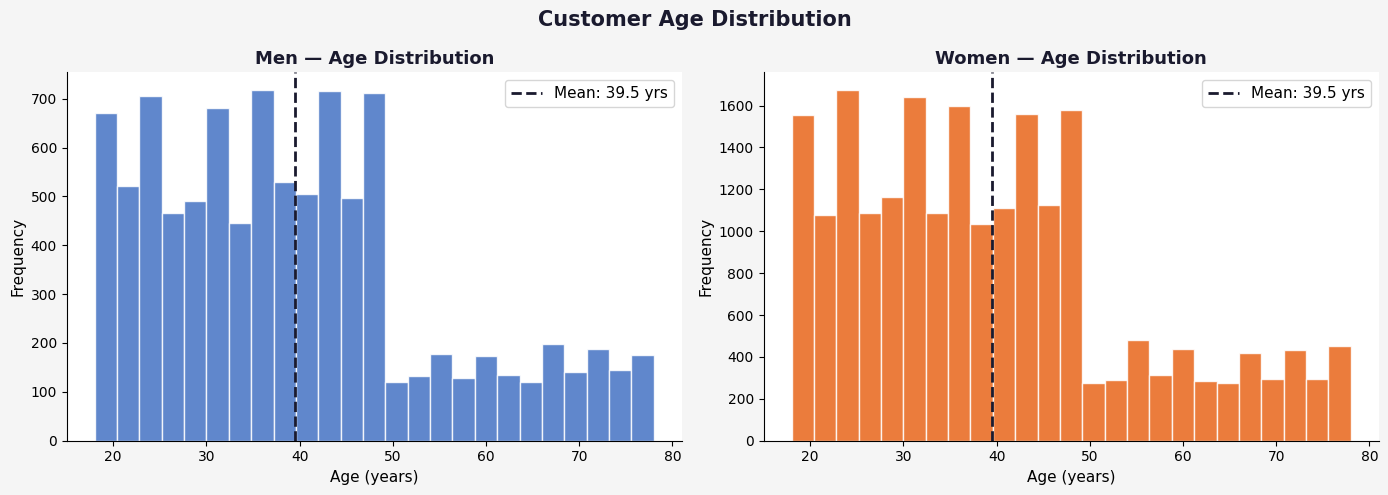

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(LIGHT_BG)
fig.suptitle("Customer Age Distribution", fontsize=15, fontweight="bold", color=DARK_BG)

for gender, color, ax in zip(["Men", "Women"], [BLUE, ORANGE], axes):
    subset = df[df["Gender"] == gender]["Age"]
    ax.hist(subset, bins=25, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(subset.mean(), color=DARK_BG, linewidth=2, linestyle="--",
               label=f"Mean: {subset.mean():.1f} yrs")
    ax.set_title(f"{gender} — Age Distribution", fontsize=13)
    ax.set_xlabel("Age (years)")
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig("chart_age_dist.png", dpi=150, bbox_inches="tight", facecolor=LIGHT_BG)
plt.show()


<a id='6'></a>
##  Section 6 — Key Business KPIs

> Summary metrics that matter to stakeholders.


In [22]:
total_revenue   = df["Amount"].sum()
total_orders    = df["Order ID"].nunique()
avg_order_value = total_revenue / total_orders
top_channel     = df.groupby("Channel")["Amount"].sum().idxmax()
top_state       = df.groupby("ship-state")["Amount"].sum().idxmax()
delivery_rate   = (df["Status"] == "Delivered").mean() * 100
women_share     = (df["Gender"] == "Women").mean() * 100
top_category    = df.groupby("Category")["Amount"].sum().idxmax()

kpis = {
    " Total Revenue"        : f"₹{total_revenue/1e6:.2f}M",
    " Total Orders"         : f"{total_orders:,}",
    " Avg Order Value"      : f"₹{avg_order_value:.0f}",
    " Top Channel"          : top_channel,
    " Top State"            : top_state,
    " Delivery Rate"        : f"{delivery_rate:.1f}%",
    " Women Share"          : f"{women_share:.1f}%",
    " Top Category"         : top_category,
}

print("=" * 45)
print("   📊  SWIFTCART 2022 KEY PERFORMANCE INDICATORS")
print("=" * 45)
for k, v in kpis.items():
    print(f"  {k:<28}  {v}")
print("=" * 45)


   📊  SWIFTCART 2022 KEY PERFORMANCE INDICATORS
   Total Revenue                ₹21.18M
   Total Orders                 28,471
   Avg Order Value              ₹744
   Top Channel                  Amazon
   Top State                    MAHARASHTRA
   Delivery Rate                92.3%
   Women Share                  69.4%
   Top Category                 Set


<a id='7'></a>
##  Section 7 — Full Dashboard 

> Recreating the SwiftCart Annual Report 2022 dashboard in a single figure
> using the same orange-blue brand palette.


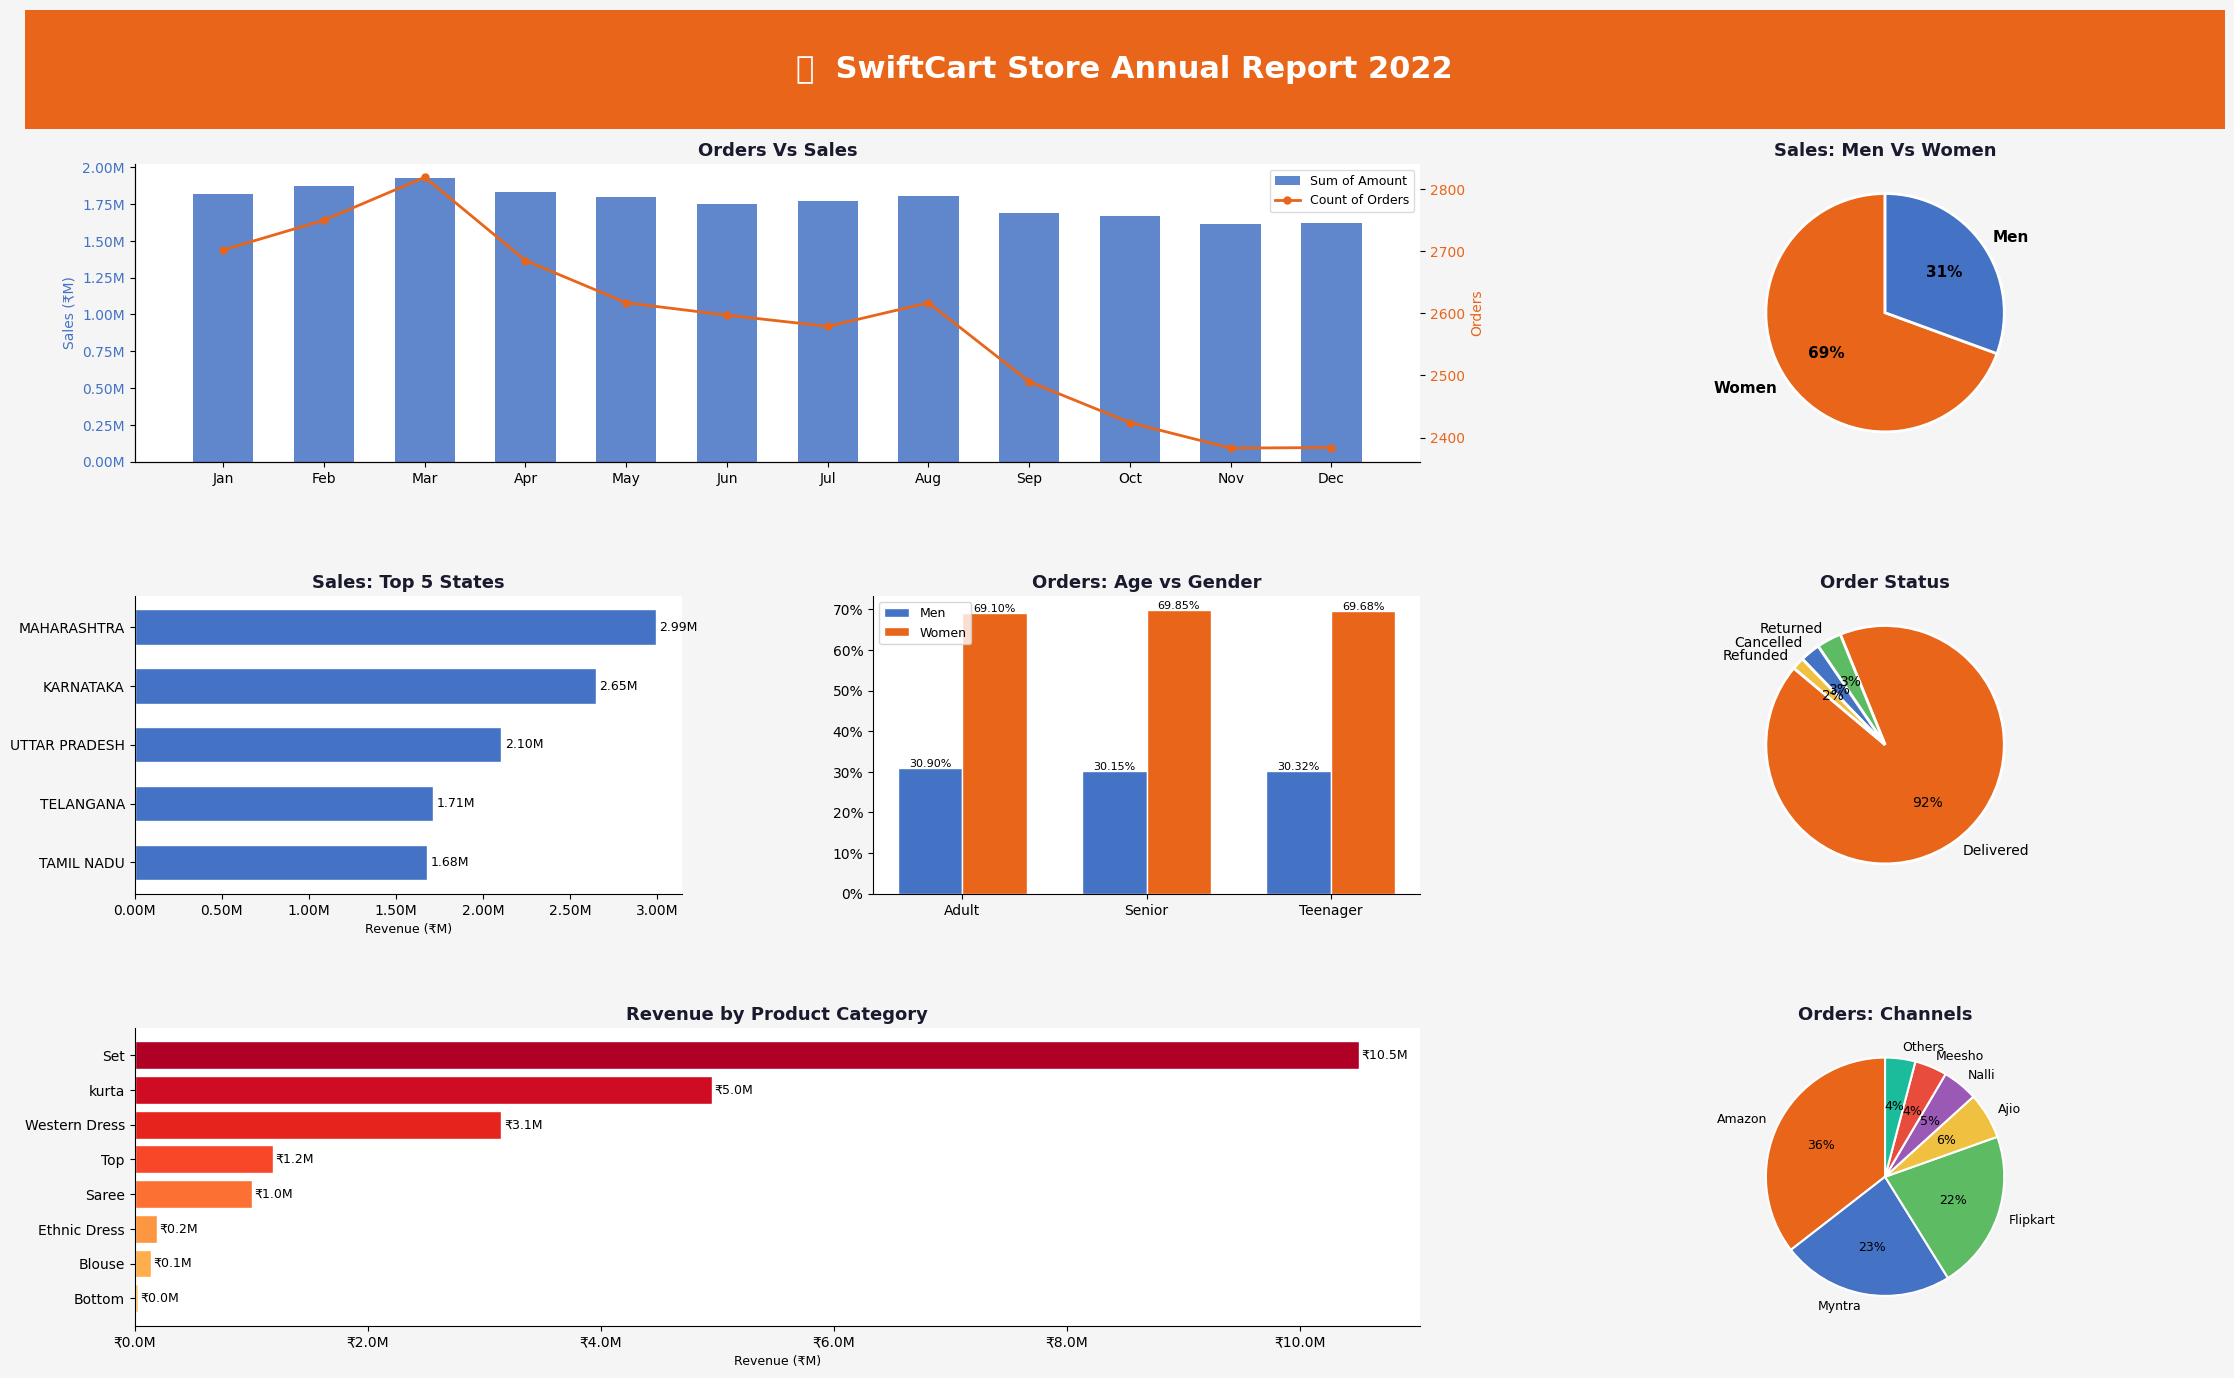

 Dashboard saved as 'swiftcart_dashboard.png'


In [23]:
# ── Pre-compute all aggregations ─────────────────────────────────────────────
monthly = df.groupby("Month_num", observed=True).agg(
    Sales  = ("Amount",   "sum"),
    Orders = ("Order ID", "count")
).reset_index()

gender_data  = df["Gender"].value_counts()
status_data  = df["Status"].value_counts()

age_gender   = df.groupby(["Age Group", "Gender"])["Order ID"].count().unstack()
age_pct      = age_gender.div(age_gender.sum(axis=1), axis=0) * 100
age_pct      = age_pct.reindex(["Adult", "Senior", "Teenager"])

top5_states  = (df.groupby("ship-state")["Amount"]
                .sum().sort_values(ascending=False).head(5))

channel_data = df.groupby("Channel")["Amount"].sum().sort_values(ascending=False)

# ── Build Dashboard Grid ──────────────────────────────────────────────────────
fig = plt.figure(figsize=(22, 14))
fig.patch.set_facecolor(LIGHT_BG)

gs = gridspec.GridSpec(3, 3, figure=fig,
                       hspace=0.45, wspace=0.35,
                       left=0.05, right=0.97,
                       top=0.89, bottom=0.06)

# ── Header ────────────────────────────────────────────────────────────────────
header_ax = fig.add_axes([0, 0.915, 1, 0.085])
header_ax.set_xlim(0, 1); header_ax.set_ylim(0, 1)
header_ax.axis("off")
header_ax.add_patch(plt.Rectangle((0,0), 1, 1, color=ORANGE, zorder=0))
header_ax.text(0.5, 0.5, "🛒  SwiftCart Store Annual Report 2022",
               ha="center", va="center", fontsize=22,
               fontweight="bold", color="white", zorder=1)

# ─────────────────────────────────────────────────────────────────────────────
# CHART 1 – Orders vs Sales (spans columns 0-1, row 0)
# ─────────────────────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0:2])
ax1.set_facecolor("white")
ax1.bar(monthly["Month_num"].astype(str), monthly["Sales"]/1e6,
        color=BLUE, alpha=0.85, width=0.6, label="Sum of Amount")
ax1.set_ylabel("Sales (₹M)", color=BLUE, fontsize=10)
ax1.tick_params(axis="y", labelcolor=BLUE)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.2f}M"))

ax1b = ax1.twinx()
ax1b.plot(monthly["Month_num"].astype(str), monthly["Orders"],
          color=ORANGE, linewidth=2, marker="o", markersize=5,
          label="Count of Orders")
ax1b.set_ylabel("Orders", color=ORANGE, fontsize=10)
ax1b.tick_params(axis="y", labelcolor=ORANGE)

ax1.set_title("Orders Vs Sales", fontsize=13, fontweight="bold")
l1, lb1 = ax1.get_legend_handles_labels()
l2, lb2 = ax1b.get_legend_handles_labels()
ax1.legend(l1+l2, lb1+lb2, loc="upper right", fontsize=9, framealpha=0.7)

# ─────────────────────────────────────────────────────────────────────────────
# CHART 2 – Sales: Men vs Women
# ─────────────────────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
ax2.set_facecolor("white")
ax2.pie(gender_data.values, labels=gender_data.index,
        autopct="%1.0f%%", startangle=90,
        colors=[ORANGE, BLUE],
        textprops={"fontsize": 11, "fontweight": "bold"},
        wedgeprops={"edgecolor": "white", "linewidth": 2})
ax2.set_title("Sales: Men Vs Women", fontsize=13, fontweight="bold")

# ─────────────────────────────────────────────────────────────────────────────
# CHART 3 – Top 5 States
# ─────────────────────────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
ax3.set_facecolor("white")
ax3.barh(top5_states.index[::-1], top5_states.values[::-1]/1e6,
         color=BLUE, edgecolor="white", height=0.6)
for i, (state, val) in enumerate(zip(top5_states.index[::-1], top5_states.values[::-1])):
    ax3.text(val/1e6 + 0.02, i, f"{val/1e6:.2f}M", va="center", fontsize=9)
ax3.set_title("Sales: Top 5 States", fontsize=13, fontweight="bold")
ax3.set_xlabel("Revenue (₹M)", fontsize=9)
ax3.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.2f}M"))

# ─────────────────────────────────────────────────────────────────────────────
# CHART 4 – Orders: Age vs Gender
# ─────────────────────────────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
ax4.set_facecolor("white")
x = np.arange(len(age_pct.index)); width = 0.35
b1 = ax4.bar(x - width/2, age_pct["Men"],   width, color=BLUE,   label="Men",   edgecolor="white")
b2 = ax4.bar(x + width/2, age_pct["Women"], width, color=ORANGE, label="Women", edgecolor="white")
for bar in list(b1) + list(b2):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f"{bar.get_height():.2f}%", ha="center", fontsize=8)
ax4.set_xticks(x); ax4.set_xticklabels(age_pct.index, fontsize=10)
ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax4.set_title("Orders: Age vs Gender", fontsize=13, fontweight="bold")
ax4.legend(fontsize=9)

# ─────────────────────────────────────────────────────────────────────────────
# CHART 5 – Order Status
# ─────────────────────────────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
ax5.set_facecolor("white")
STATUS_COLORS = {"Delivered": ORANGE, "Cancelled": BLUE,
                 "Returned": "#5DBB63", "Refunded": ACCENT}
sc = [STATUS_COLORS.get(s, GREY) for s in status_data.index]
ax5.pie(status_data.values, labels=status_data.index,
        autopct="%1.0f%%", startangle=140,
        colors=sc,
        textprops={"fontsize": 10},
        wedgeprops={"edgecolor": "white", "linewidth": 2})
ax5.set_title("Order Status", fontsize=13, fontweight="bold")

# ─────────────────────────────────────────────────────────────────────────────
# CHART 6 – Orders: Channels
# ─────────────────────────────────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[2, 2])
ax6.set_facecolor("white")
ch_colors = [ORANGE, BLUE, "#5DBB63", ACCENT, "#9B59B6", "#E74C3C", "#1ABC9C"]
ax6.pie(channel_data.values, labels=channel_data.index,
        autopct="%1.0f%%", startangle=90,
        colors=ch_colors,
        textprops={"fontsize": 9},
        wedgeprops={"edgecolor": "white", "linewidth": 1.5})
ax6.set_title("Orders: Channels", fontsize=13, fontweight="bold")

# ─────────────────────────────────────────────────────────────────────────────
# CHART 7 – Category Revenue (row 2, col 0-1)
# ─────────────────────────────────────────────────────────────────────────────
ax7 = fig.add_subplot(gs[2, 0:2])
ax7.set_facecolor("white")
cat_rev = df.groupby("Category")["Amount"].sum().sort_values()
colors_cat = plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(cat_rev)))
bars7 = ax7.barh(cat_rev.index, cat_rev.values/1e6, color=colors_cat, edgecolor="white")
for bar, val in zip(bars7, cat_rev.values):
    ax7.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
             f"₹{val/1e6:.1f}M", va="center", fontsize=9)
ax7.set_title("Revenue by Product Category", fontsize=13, fontweight="bold")
ax7.set_xlabel("Revenue (₹M)", fontsize=9)
ax7.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"₹{x:.1f}M"))

# ── Save ──────────────────────────────────────────────────────────────────────
plt.savefig("swiftcart_dashboard.png", dpi=180, bbox_inches="tight", facecolor=LIGHT_BG)
plt.show()
print(" Dashboard saved as 'swiftcart_dashboard.png'")


<a id='8'></a>
##  Section 8 — Insights & Recommendations

---

###  Key Findings

| # | Finding | Implication |
|---|---------|-------------|
| 1 | **March** is the peak month for both revenue and order volume | Run marketing campaigns in Feb to amplify the peak |
| 2 | **Women (64%)** dominate purchases across all channels | Prioritise women-centric product lines and creatives |
| 3 | **Amazon (35%)** is the top revenue channel | Invest in Amazon Ads and Prime Day promotions |
| 4 | **Maharashtra** generates the highest state revenue (₹2.99M) | Expand warehouse/logistics presence in Mumbai |
| 5 | **Delivery rate is 92%** — low return & cancel rates | Strong fulfilment performance; target 95%+ |
| 6 | **Adult Women** are the biggest age-gender segment | Personalise recommendations for 25–40F customers |
| 7 | **Kurta & Set** are the top-selling categories | Ensure high inventory availability before peak months |

###  Strategic Recommendations

-  **Target Adult Women** with personalised email & push campaigns — they drive ~35% of all orders.  
-  **Ramp inventory in Feb** to absorb the March spike without stockouts.  
-  **Diversify from Amazon** — Myntra & Flipkart together match Amazon; a dual strategy reduces platform risk.  
-  **Expand in Tier-2 states** — DELHI and ANDHRA PRADESH show strong growth potential.  
-  **Reduce Returned + Cancelled** orders from 6% → 3% by improving size guide and product descriptions.


>  *Notebook by Zohair Baloch | Data Analyst Intern project | [LinkedIn](https://linkedin.com/in/zohair-baloch-data-analyst) | [Kaggle](https://kaggle.com/zohairbaloch) | [GitHub](https://github.com/zohairbaloch-64)*